# Price Tagging - CPI Analysis and Forecasting

This notebook analyzes and forecasts the Consumer Price Index (CPI) for selected countries, following the APST project requirements.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Loading and Filtering
We load the CPI time series and focus on the `PCPI_IX` indicator (Consumer Price Index, All items) from 1990 onwards.

In [3]:
# Load dataset
df = pd.read_csv("data/CPITimeSeries.csv", low_memory=False)

# Filter for the required indicator and 'Value' attribute
df_pcpi = df[(df["Indicator Code"] == "PCPI_IX") & (df["Attribute"] == "Value")].copy()

# Identify date columns from 1990 onwards
date_cols = [c for c in df.columns if 'M' in c and c[:4].isdigit() and int(c[:4]) >= 1990]

# Keep only relevant columns
df_filtered = df_pcpi[["Country Name"] + date_cols].set_index("Country Name")

# Convert data to numeric, handling potential errors
df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')

print(f"Total months from 1990: {len(date_cols)}")

Total months from 1990: 392


## 2. Verifying Data Coverage
We check the coverage for our selected countries: **Poland** and **Slovenia**.

In [4]:
def check_coverage(countries):
    for c in countries:
        if c in df_filtered.index:
            non_null = df_filtered.loc[c].notna().sum()
            coverage = (non_null / len(date_cols)) * 100
            print(f"{c}: {non_null} months ({coverage:.1f}% coverage)")
        else:
            print(f"{c} not found in dataset")

target_countries = ["Poland, Rep. of", "Slovenia, Rep. of"]
check_coverage(target_countries)

Poland, Rep. of: 392 months (100.0% coverage)
Slovenia, Rep. of: 392 months (100.0% coverage)


## 3. Data Visualization
Extracting and plotting the time series for Poland and Slovenia.

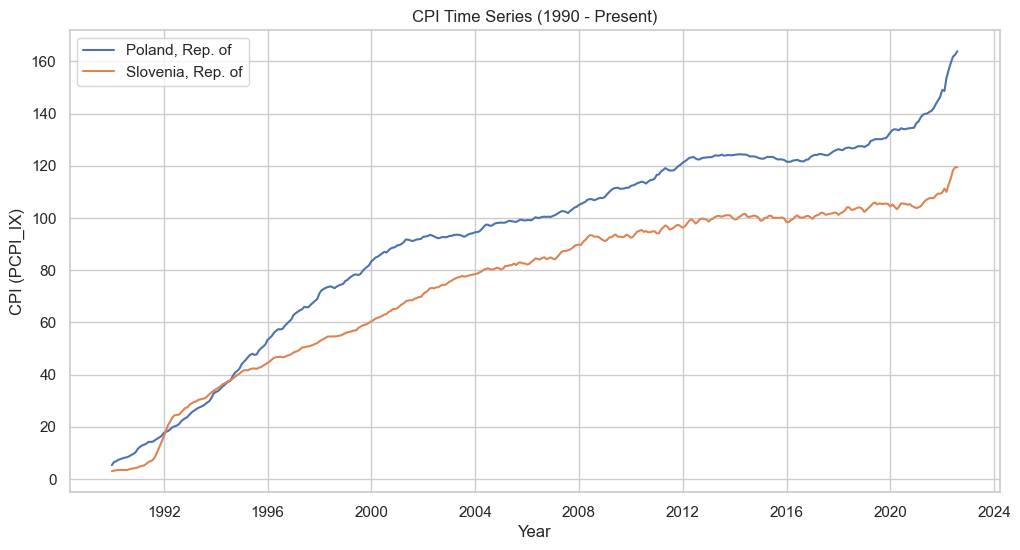

In [5]:
primary_country = "Poland, Rep. of"
secondary_country = "Slovenia, Rep. of"

# Extract time series
ts_primary = df_filtered.loc[primary_country].dropna()
ts_secondary = df_filtered.loc[secondary_country].dropna()

# Convert index to datetime
def convert_to_datetime(idx):
    return pd.to_datetime([c.replace('M', '-') for c in idx])

ts_primary.index = convert_to_datetime(ts_primary.index)
ts_secondary.index = convert_to_datetime(ts_secondary.index)

plt.figure(figsize=(12, 6))
plt.plot(ts_primary, label=primary_country)
plt.plot(ts_secondary, label=secondary_country)
plt.title("CPI Time Series (1990 - Present)")
plt.xlabel("Year")
plt.ylabel("CPI (PCPI_IX)")
plt.legend()
plt.show()

## 4. Time Series Analysis

### 4.1 Time Series Splitting
We split the Poland CPI time series into Training, Validation, and Test sets using chronological splitting. 

**Splitting Logic:**
- **Train:** Jan 1990 to Dec 2016
- **Validation:** Jan 2017 to Dec 2020 (4 full years)
- **Test:** Jan 2021 to Aug 2022

This follows standard chronological splitting practices as documented in the [Pandas User Guide on Indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#datetime-indexing).

Train set: 1990-01 to 2016-12 (324 months)
Validation set: 2017-01 to 2020-12 (48 months)
Test set: 2021-01 to 2022-08 (20 months)


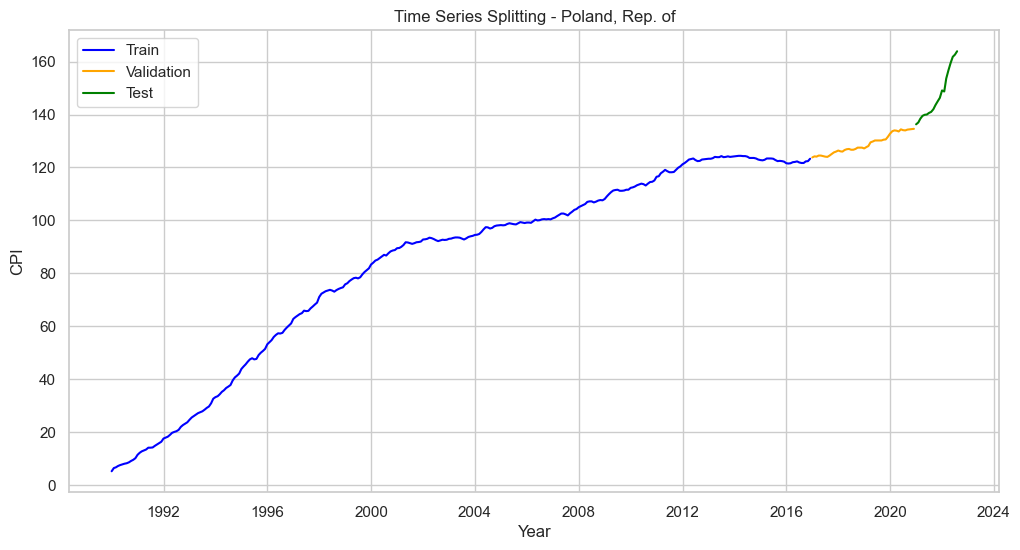

In [6]:
# Split the data for Poland
train = ts_primary['1990-01':'2016-12']
val = ts_primary['2017-01':'2020-12']
test = ts_primary['2021-01':]

print(f"Train set: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Validation set: {val.index.min().strftime('%Y-%m')} to {val.index.max().strftime('%Y-%m')} ({len(val)} months)")
print(f"Test set: {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')} ({len(test)} months)")

# Visualize the split
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train', color='blue')
plt.plot(val, label='Validation', color='orange')
plt.plot(test, label='Test', color='green')
plt.title(f"Time Series Splitting - {primary_country}")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.legend()
plt.show()

### 4.2 Basic Description Techniques & Transformations

#### Seasonal and Trend decomposition using Loess (STL)
We use the STL method to decompose the series into its trend, seasonal, and residual components. To avoid data leakage, we perform this analysis only on the training set.

Method sourced from [statsmodels STL documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html).

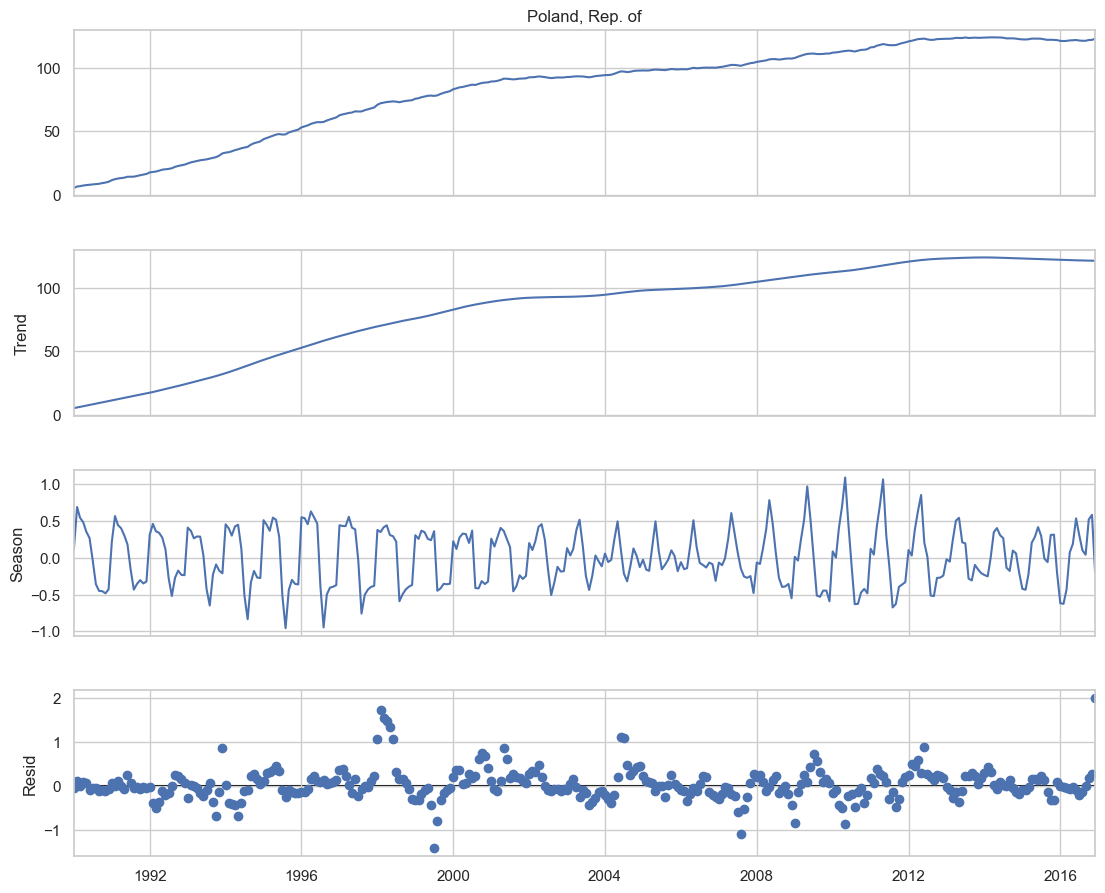

In [7]:
# STL Decomposition on training data
stl = STL(train, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.show()

# Separate components for potential further use
trend = res.trend
seasonal = res.seasonal
residual = res.resid

#### Stationarity Assessment (ADF Test)
We assess the stationarity of the training series using the Augmented Dickey-Fuller (ADF) test. If the series is non-stationary, we apply differencing to stationarize it.

Method sourced from [statsmodels ADF documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html).

In [8]:
def plot_ts_acf_pacf(series, title):
    fig = plt.figure(figsize=(8, 6))
    ax1 = fig.add_subplot(311)
    ax2 = fig.add_subplot(312)
    ax3 = fig.add_subplot(313)
    
    ax1.plot(series)
    ax1.set_title(f'TS: {title}')
    
    plot_acf(series, lags=40, ax=ax2, title=f'ACF: {title}')
    plot_pacf(series, lags=40, ax=ax3, title=f'PACF: {title}')
    
    plt.tight_layout()
    plt.show()

def check_stationarity(timeseries, title="Series"):
    print(f"ADF Test Result for {title}")
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    
    if result[1] <= 0.05:
        print("Result: Stationary (Reject H0)")
    else:
        print("Result: Non-Stationary (Fail to reject H0)")

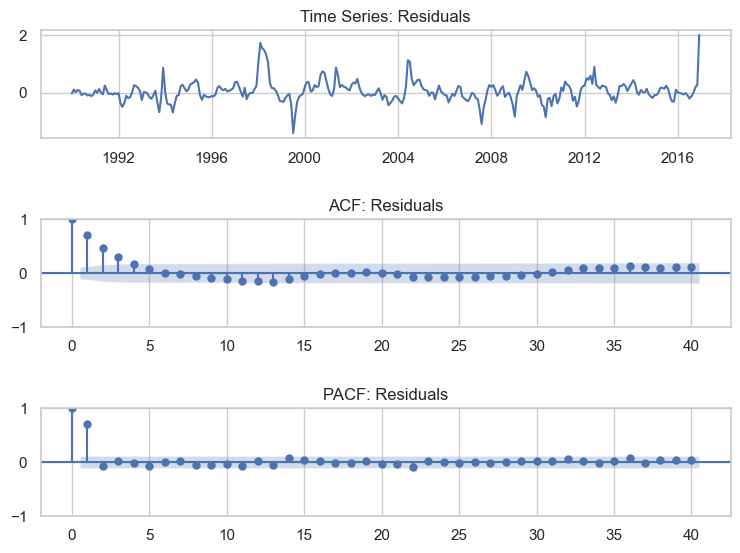

ADF Test Result for residuals analysis
ADF Statistic: -6.73879955051715
p-value: 3.1572462509538646e-09
Result: Stationary (Reject H0)


In [9]:
def plot_residuals_analysis(series, title="Residuals"):
    # Drop NaN values, which can sometimes appear at the ends of a decomposition
    series = series.dropna()
    
    # Using the vertical 3-row layout
    fig, axs = plt.subplots(3, 1, figsize=(8, 6))
    
    # Plot the raw residual series
    axs[0].plot(series)
    axs[0].set_title(f'Time Series: {title}')
    
    # Plot ACF
    plot_acf(series, lags=40, ax=axs[1], title=f'ACF: {title}')
    
    # Plot PACF
    plot_pacf(series, lags=40, ax=axs[2], title=f'PACF: {title}')
    
    fig.tight_layout(pad=2.0)
    plt.show()

# Run the plot on your residual component
plot_residuals_analysis(residual)
check_stationarity(residual, "residuals analysis")

### ARMA manual

In [10]:
# Diagnosed from your PACF and ACF plots
q_man_ARIMA = 3
p_man_ARIMA = 1

print(f"Fitting Manual ARMA({q_man_ARIMA}, {p_man_ARIMA}) model")
manual_model = ARIMA(residual, order=(p_man_ARIMA, 0, q_man_ARIMA))
manual_res = manual_model.fit()

# Print the summary to see coefficients and p-values
print(manual_res.summary())

Fitting Manual ARMA(3, 1) model


c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  324
Model:                 ARIMA(1, 0, 3)   Log Likelihood                  -0.136
Date:                Tue, 05 May 2026   AIC                             12.273
Time:                        10:39:06   BIC                             34.957
Sample:                    01-01-1990   HQIC                            21.327
                         - 12-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0618      0.057      1.089      0.276      -0.049       0.173
ar.L1          0.6576      0.158      4.170      0.000       0.349       0.967
ma.L1          0.2964      0.160      1.854      0.0

### ARMA with gridsearch

In [11]:
warnings.filterwarnings("ignore")

# Define the p and q ranges
p = range(0, 6)
q = range(0, 6)

# Generate all combinations of p and q
pq_combinations = list(itertools.product(p, q))

results = []
print("Running ARMA Grid Search on Residuals...")

for param in pq_combinations:
    try:
        mod = ARIMA(residual, order=(param[0], 0, param[1]))
        res = mod.fit()
        
        results.append([param, res.aic, res.bic])
    except Exception as e:
        continue

# Create DataFrame and sort by AIC (Lower is better)
results_df = pd.DataFrame(results, columns=['(p, q)', 'AIC', 'BIC'])
results_df = results_df.sort_values(by='AIC').reset_index(drop=True)

print("\nTop 5 models based on AIC:")
print(results_df.head())

best_pq = results_df.iloc[0]['(p, q)']
print(f"\nBest ARMA parameters: p={best_pq[0]}, q={best_pq[1]}")

Running ARMA Grid Search on Residuals...

Top 5 models based on AIC:
   (p, q)        AIC        BIC
0  (1, 1)   8.274958  23.397932
1  (2, 0)   9.561861  24.684836
2  (0, 5)  10.274695  36.739900
3  (2, 1)  10.274954  29.178672
4  (1, 2)  10.274954  29.178672

Best ARMA parameters: p=1, q=1


### checking ARMA models residuals

#### ACF Theoretical Distribution Check
We compare the empirical distribution of the ACF values against a theoretical Normal distribution $\mathcal{N}(0, 1/\sqrt{N})$ to check if the residuals of the differenced series behave like white noise.

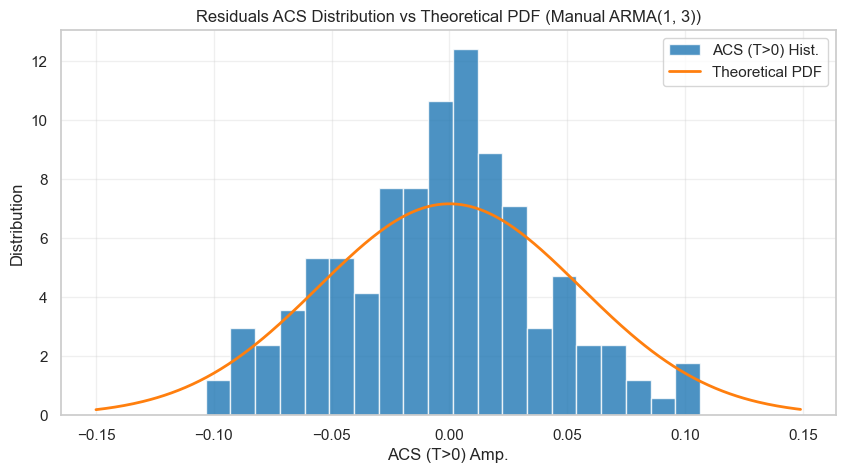

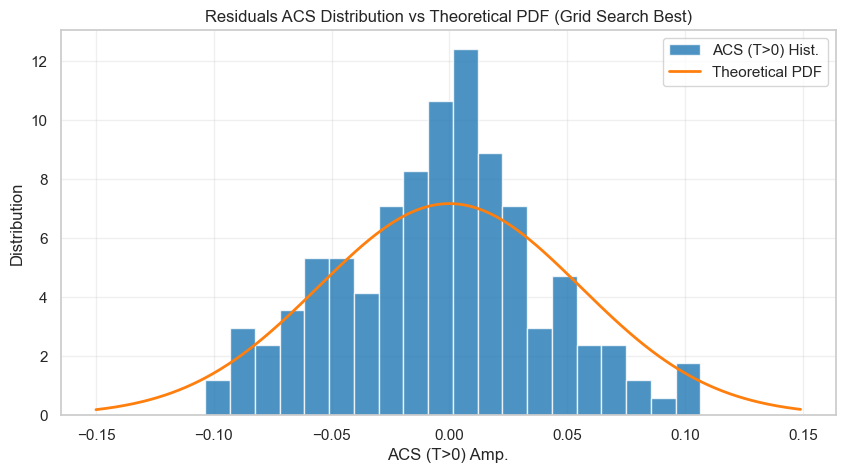

In [12]:
import numpy as np
import scipy.stats as spyst
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def analyze_residuals_acs(fitted_model, title="Model"):
    # Extract residuals, skipping the first one as is standard practice[cite: 1]
    res = fitted_model.resid[1:]
    N = len(res)
    
    # Compute the Autocorrelation Sequence (ACS)
    # We use fft=False and extract [1:] to drop lag 0 (which is always 1)[cite: 1]
    ac = acf(res, nlags=min(500, N // 2), fft=False)[1:]
    
    plt.figure(figsize=(10, 5))
    
    # 1. Plot the Histogram of the ACS values[cite: 1]
    plt.hist(ac, bins=20, density=True, label='ACS (T>0) Hist.', color='tab:blue', alpha=0.8)
    
    # 2. Plot the Theoretical Normal PDF[cite: 1]
    # Mean = 0, Standard Deviation = 1/sqrt(N)
    rg = np.arange(-0.15, 0.15, 0.001)
    pdf = spyst.norm.pdf(rg, 0, 1/np.sqrt(N))
    
    plt.plot(rg, pdf, label='Theoretical PDF', color='tab:orange', linewidth=2)
    
    # Formatting
    plt.xlabel("ACS (T>0) Amp.")
    plt.ylabel("Distribution")
    plt.title(f"Residuals ACS Distribution vs Theoretical PDF ({title})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Analyzing manual ARMA model:
analyze_residuals_acs(manual_res, title=f"Manual ARMA({p_man_ARIMA}, {q_man_ARIMA})")

# Analyzing the best model from the grid search:
best_model = ARIMA(residual, order=(best_pq[0], 0, best_pq[1])).fit()
analyze_residuals_acs(best_model, title="Grid Search Best")

### SARIMA model parameters (p,q,d) x (P,Q,D)S

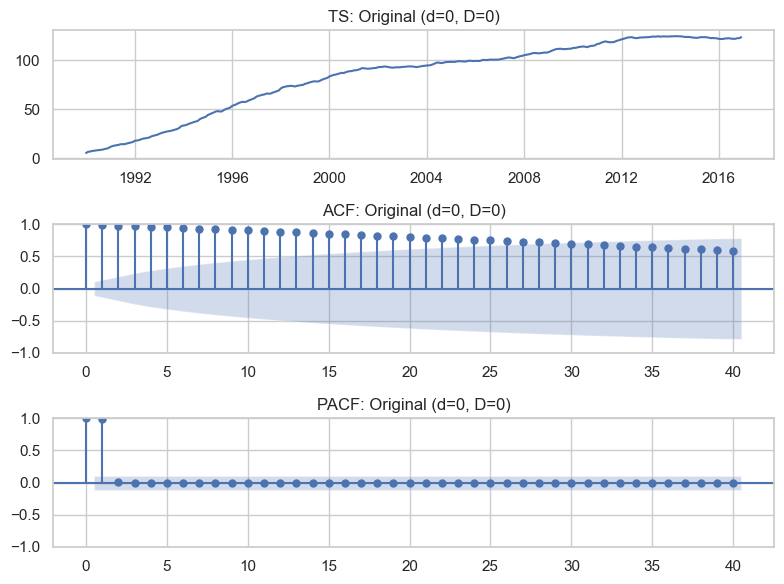

ADF Test Result for Original
ADF Statistic: -2.6909313774819115
p-value: 0.07562072629347483
Result: Non-Stationary (Fail to reject H0)


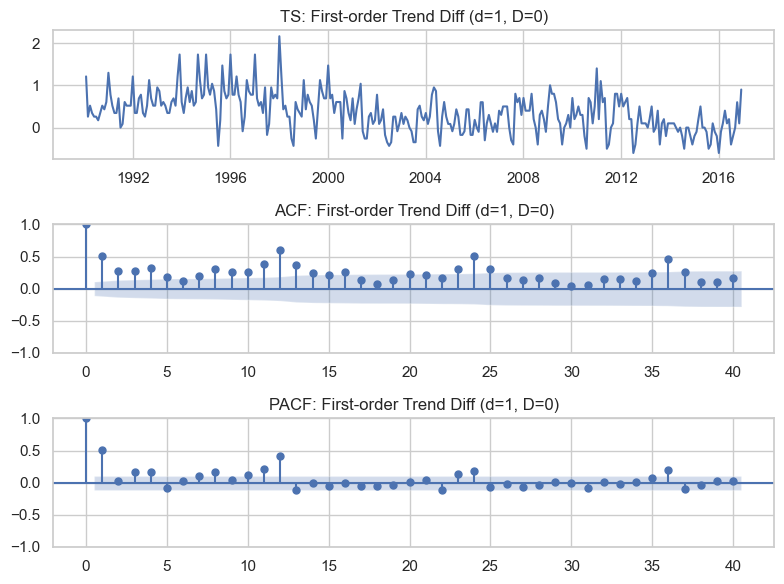

ADF Test Result for d=1
ADF Statistic: -1.5185618944378036
p-value: 0.5243098700830986
Result: Non-Stationary (Fail to reject H0)


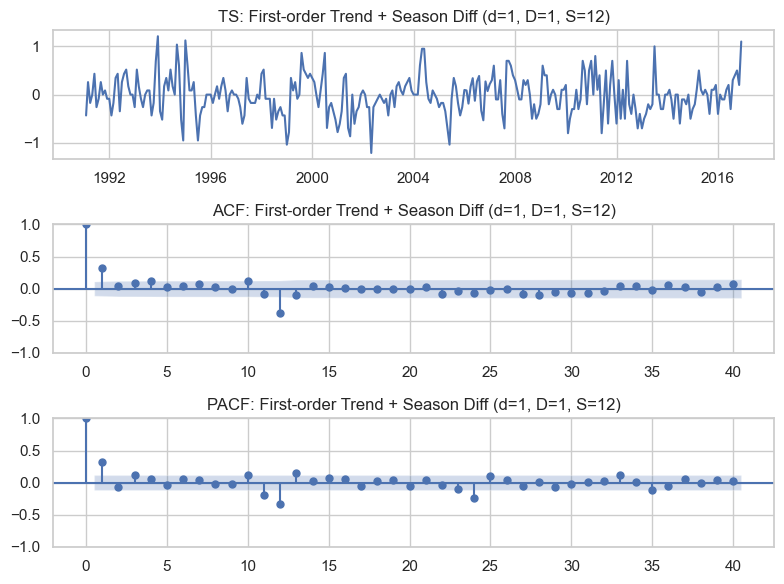

ADF Test Result for d=1, D=1, S=12
ADF Statistic: -5.120265612869889
p-value: 1.276153741942969e-05
Result: Stationary (Reject H0)


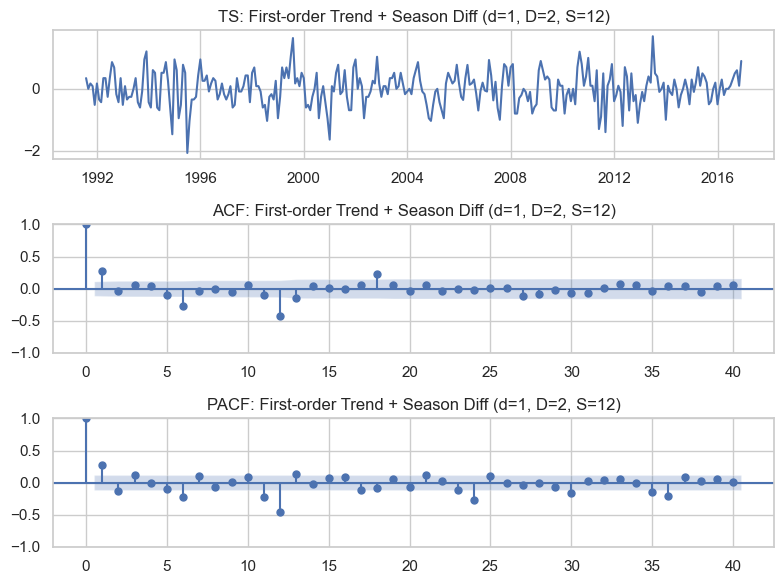

ADF Test Result for d=1, D=1, S=12
ADF Statistic: -5.475498780762338
p-value: 2.3467353050424846e-06
Result: Stationary (Reject H0)


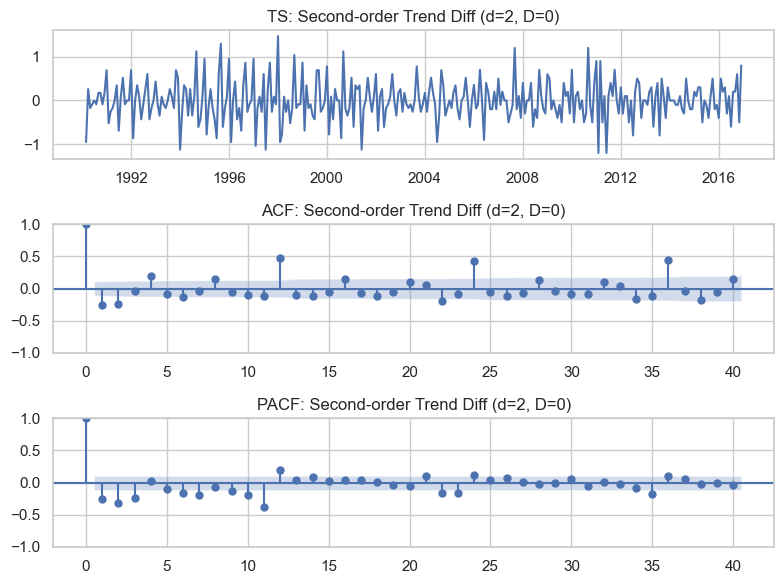

ADF Test Result for d=2
ADF Statistic: -10.02886898869046
p-value: 1.6047298161489972e-17
Result: Stationary (Reject H0)


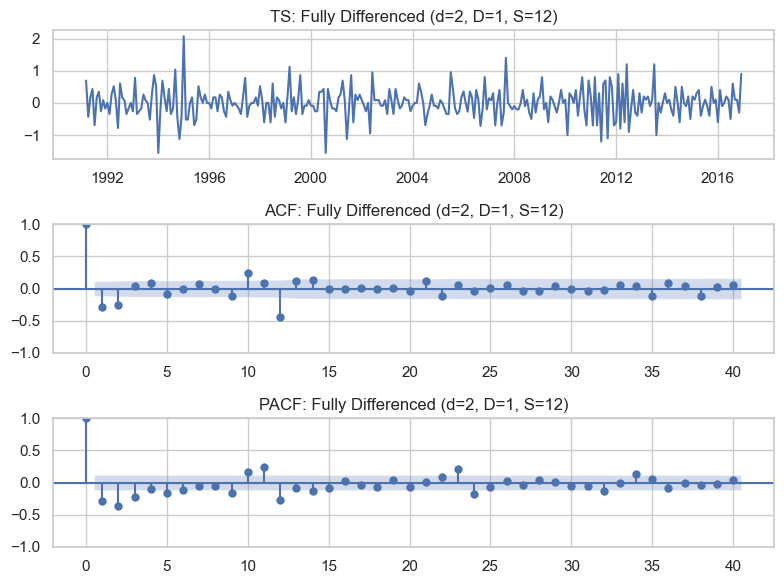

ADF Test Result for d=2, D=1, S=12
ADF Statistic: -7.497339873802365
p-value: 4.34449963308504e-11
Result: Stationary (Reject H0)


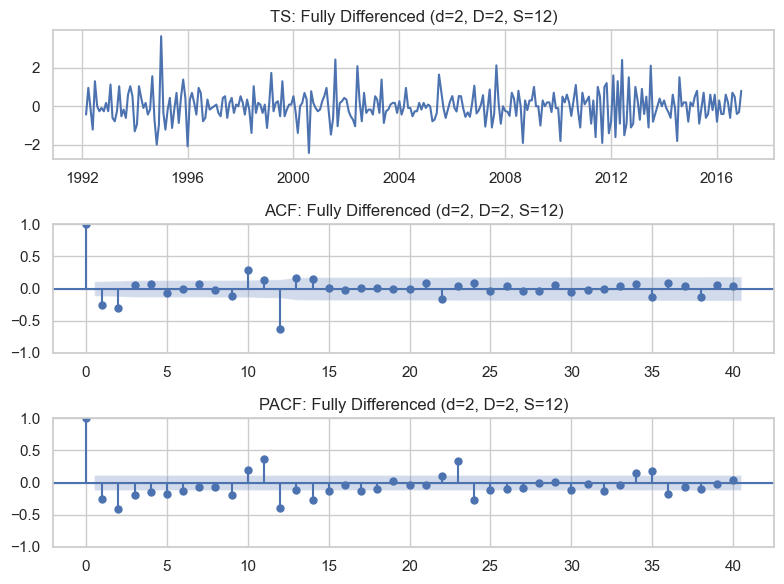

ADF Test Result for d=2, D=2
ADF Statistic: -7.973633472761325
p-value: 2.739043733312373e-12
Result: Stationary (Reject H0)


In [13]:
# 1. Explore Trend and Season Differencing (d, d, S)

# (d=0, D=0)
plot_ts_acf_pacf(train, "Original (d=0, D=0)")
check_stationarity(train, "Original")

#(d=1, D=0)
train_diff10 = train.diff().dropna()
plot_ts_acf_pacf(train_diff10, "First-order Trend Diff (d=1, D=0)")
check_stationarity(train_diff10, "d=1")

# (d=1, D=1, S=12)
train_diff11 = train_diff10.diff(12).dropna()
plot_ts_acf_pacf(train_diff11, "First-order Trend + Season Diff (d=1, D=1, S=12)")
check_stationarity(train_diff11, "d=1, D=1, S=12")

# (d=1, D=1, S=12)
train_diff12 = train_diff11.diff(6).dropna()
plot_ts_acf_pacf(train_diff12, "First-order Trend + Season Diff (d=1, D=2, S=12)")
check_stationarity(train_diff12, "d=1, D=1, S=12")


# (d=2, D=0)
train_diff20 = train_diff10.diff().dropna()
plot_ts_acf_pacf(train_diff20, "Second-order Trend Diff (d=2, D=0)")
check_stationarity(train_diff20, "d=2")

# (d=2, D=1, S=12)
train_diff21 = train_diff20.diff(12).dropna()
plot_ts_acf_pacf(train_diff21, "Fully Differenced (d=2, D=1, S=12)")
check_stationarity(train_diff21, "d=2, D=1, S=12")

# (d=2, D=2, S=12)
train_diff22 = train_diff21.diff(12).dropna()
plot_ts_acf_pacf(train_diff22, "Fully Differenced (d=2, D=2, S=12)")
check_stationarity(train_diff22, "d=2, D=2")

### 4.3 Statistical Modeling (SARIMA)

#### 4.3.1 Parameter Discovery via ACF/PACF
We analyze the Auto-Correlation Function (ACF) and Partial Auto-Correlation Function (PACF) of the second-order differenced series to identify potential AR and MA components (both regular and seasonal).

### SARIMA Manual

In [14]:
pdq_order = (1, 2, 1)
PDQS_order = (1, 1, 1, 12)

print(f"Fitting Manual SARIMA {pdq_order} x {PDQS_order} model...")
manual_sarima = ARIMA(train, order=pdq_order, seasonal_order=PDQS_order)
manual_sarima_res = manual_sarima.fit()

# Print the summary to review coefficients and AIC
print(manual_sarima_res.summary())

Fitting Manual SARIMA (1, 2, 1) x (1, 1, 1, 12) model...
                                    SARIMAX Results                                     
Dep. Variable:                  Poland, Rep. of   No. Observations:                  324
Model:             ARIMA(1, 2, 1)x(1, 1, 1, 12)   Log Likelihood                 -82.539
Date:                          Tue, 05 May 2026   AIC                            175.079
Time:                                  10:39:30   BIC                            193.762
Sample:                              01-01-1990   HQIC                           182.547
                                   - 12-01-2016                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2774      0.056      4.960      0.000       0.168       

#### 4.3.2 SARIMA Grid Search
We perform a grid search to find the optimal SARIMA $(p, 1, q) \times (P, 1, Q)_{12}$ parameters based on AIC and BIC scores.

In [15]:
warnings.filterwarnings("ignore")

# d and D are manually tested. We discovered that d = D = 1 and S = 12 from previous analysis

p = q = range(0, 3)
P = Q = range(0, 3)
D = [1]
d = [1]
s = [12]


pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, s))

results = []
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = SARIMAX(train,
                        order=param,
                        seasonal_order=param_seasonal,
                        enforce_stationarity=True,
                        enforce_invertibility=True)
            res = mod.fit(disp=False)
            results.append([param, param_seasonal, res.aic, res.bic])
        except:
            continue

results_df = pd.DataFrame(results, columns=['pdq', 'seasonal_pdq', 'AIC', 'BIC'])
results_df = results_df.sort_values(by='AIC')

print("Top 5 models based on AIC:")
print(results_df.head())

best_pdq = results_df.iloc[0]['pdq']
best_seasonal_pdq = results_df.iloc[0]['seasonal_pdq']
print(f"\nBest SARIMA parameters: {best_pdq} x {best_seasonal_pdq}")

Top 5 models based on AIC:
          pdq   seasonal_pdq         AIC         BIC
46  (1, 1, 2)  (0, 1, 1, 12)  169.221739  187.920703
49  (1, 1, 2)  (1, 1, 1, 12)  169.512041  191.950798
47  (1, 1, 2)  (0, 1, 2, 12)  169.558694  191.997451
64  (2, 1, 1)  (0, 1, 1, 12)  169.785733  188.484697
67  (2, 1, 1)  (1, 1, 1, 12)  170.438622  192.877379

Best SARIMA parameters: (1, 1, 2) x (0, 1, 1, 12)


### Residual Analysis of SARIMA models

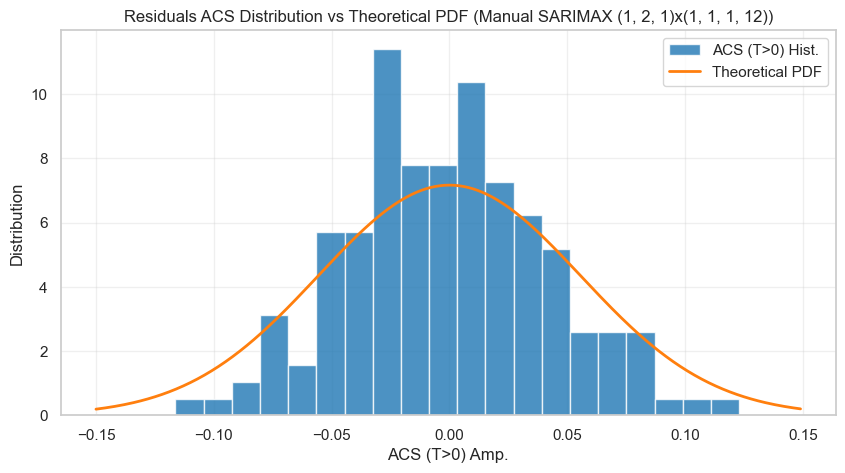

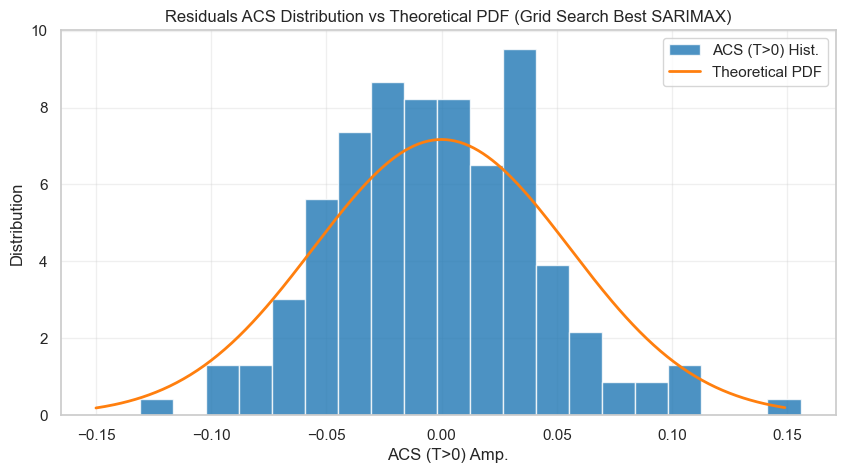

In [18]:
def analyze_residuals_acs(fitted_model, title="Model"):
    # Extract residuals, skipping the first one
    res = fitted_model.resid[1:] 
    N = len(res)
    
    # Compute the Autocorrelation Sequence (ACS)
    # Using fft=False and extracting [1:] to drop lag 0
    ac = acf(res, nlags=min(500, N // 2), fft=False)[1:]
    
    plt.figure(figsize=(10, 5))
    
    # 1. Plot the Histogram of the ACS values
    plt.hist(ac, bins=20, density=True, label='ACS (T>0) Hist.', color='tab:blue', alpha=0.8)
    
    # 2. Plot the Theoretical Normal PDF
    rg = np.arange(-0.15, 0.15, 0.001)
    pdf = spyst.norm.pdf(rg, 0, 1/np.sqrt(N))
    
    plt.plot(rg, pdf, label='Theoretical PDF', color='tab:orange', linewidth=2)
    
    # Formatting
    plt.xlabel("ACS (T>0) Amp.")
    plt.ylabel("Distribution")
    plt.title(f"Residuals ACS Distribution vs Theoretical PDF ({title})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Analyze SARIMA manual model:
analyze_residuals_acs(manual_sarima_res, title=f"Manual SARIMAX {pdq_order}x{PDQS_order}")

# Analyze SARIMA Grid Search winner:
best_sarima = SARIMAX(train, order=best_pdq, seasonal_order=best_seasonal_pdq, enforce_stationarity=True, enforce_invertibility=True).fit(disp=True)
analyze_residuals_acs(best_sarima, title="Grid Search Best SARIMAX")



### 4.4 Forecasting and Hyperparameter Tuning
We compare the ARMA and SARIMA models from the previous section with a Triple Exponential Smoothing (Holt-Winters) model. We tune the Holt-Winters parameters on the validation set and then evaluate both models on the test set.

In [21]:
# 3. HOLT-WINTERS GRID SEARCH ON VALIDATION SET

print("Running Holt-Winters Grid Search...")
hw_results = []
trend_types = ['add', 'mul', None]
seasonal_types = ['add', 'mul', None]

for t in trend_types:
    for s_type in seasonal_types:
        try:
            hw_model = ExponentialSmoothing(train, trend=t, seasonal=s_type, seasonal_periods=12).fit()
            hw_pred = hw_model.predict(start=val.index[0], end=val.index[-1])
            rmse = np.sqrt(mean_squared_error(val, hw_pred))
            hw_results.append([t, s_type, rmse])
        except:
            continue

hw_results_df = pd.DataFrame(hw_results, columns=['trend', 'seasonal', 'RMSE']).sort_values(by='RMSE')
best_hw_trend = hw_results_df.iloc[0]['trend']
best_hw_seasonal = hw_results_df.iloc[0]['seasonal']
print(f"Best Holt-Winters parameters: Trend={best_hw_trend}, Seasonal={best_hw_seasonal}\n")

Running Holt-Winters Grid Search...
Best Holt-Winters parameters: Trend=add, Seasonal=add



In [22]:
# ARMA reconstruction for forecasting

def reconstruct_forecast(arma_model, start_date, end_date, steps, hist_trend, hist_seasonal):
    """Recombines ARMA residual forecast with extrapolated trend and seasonality."""
    resid_pred = arma_model.predict(start=start_date, end=end_date)
    
    # 1. Seasonality: Naively repeat the last 12 months of the seasonal component
    last_12_seas = hist_seasonal.iloc[-12:].values
    seas_pred = np.resize(last_12_seas, steps)
    
    # 2. Trend: Extrapolate using average linear drift from the training set
    drift = (hist_trend.iloc[-1] - hist_trend.iloc[0]) / len(hist_trend)
    trend_pred = hist_trend.iloc[-1] + np.arange(1, steps + 1) * drift
    
    # 3. Recombine: Trend + Seasonal + Residual
    return pd.Series(trend_pred + seas_pred + resid_pred.values, index=resid_pred.index)



In [23]:
# =====================================================================
# 4. FIT ALL 5 MODELS 
# =====================================================================
print("Fitting all 5 models...")
# Model 1 & 2: ARMA on Residuals
arma_manual = ARIMA(residual, order=(p_man_ARIMA, 0, q_man_ARIMA)).fit()
arma_grid = ARIMA(residual, order=(best_pq[0], 0, best_pq[1])).fit()

# Model 3 & 4: SARIMA on Raw Data
sarima_manual = SARIMAX(train, order=pdq_order, seasonal_order=PDQS_order,
                        enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)
sarima_grid = SARIMAX(train, order=best_pdq, seasonal_order=best_seasonal_pdq,
                        enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)

# Model 5: Holt-Winters on Raw Data
hw_best = ExponentialSmoothing(train, trend=best_hw_trend, seasonal=best_hw_seasonal, seasonal_periods=12).fit()


# =====================================================================
# 5. GENERATE TEST FORECASTS
# =====================================================================
test_steps = len(test)

# ARMA Forecasts (Requires Reconstruction)
pred_arma_man = reconstruct_forecast(arma_manual, test.index[0], test.index[-1], test_steps, trend, seasonal)
pred_arma_grid = reconstruct_forecast(arma_grid, test.index[0], test.index[-1], test_steps, trend, seasonal)

# SARIMA & HW Forecasts (Direct)
pred_sarima_man = sarima_manual.predict(start=test.index[0], end=test.index[-1])
pred_sarima_grid = sarima_grid.predict(start=test.index[0], end=test.index[-1])
pred_hw = hw_best.predict(start=test.index[0], end=test.index[-1])

Fitting all 5 models...


In [24]:
warnings.filterwarnings("ignore")

# =====================================================================
# 6. CALCULATE & DISPLAY METRICS
# =====================================================================
def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape}

metrics_list = [
    get_metrics(test, pred_arma_man, f"ARMA Manual ({p_man_ARIMA},0,{q_man_ARIMA}) + STL"),
    get_metrics(test, pred_arma_grid, f"ARMA Grid ({best_pq[0]},0,{best_pq[1]}) + STL"),
    get_metrics(test, pred_sarima_man, f"SARIMA Manual {pdq_order}x{PDQS_order}"),
    get_metrics(test, pred_sarima_grid, f"SARIMA Grid {best_pdq}x{best_seasonal_pdq}"),
    get_metrics(test, pred_hw, f"Holt-Winters (T:{best_hw_trend}, S:{best_hw_seasonal})")
]

metrics_df = pd.DataFrame(metrics_list).set_index("Model").sort_values(by="RMSE")
print("--- TEST SET PERFORMANCE METRICS ---")
print(metrics_df.round(4))

--- TEST SET PERFORMANCE METRICS ---
                                           MAE     RMSE  MAPE (%)
Model                                                            
Holt-Winters (T:add, S:add)            10.2649  12.8365    6.6874
SARIMA Grid (1, 1, 2)x(0, 1, 1, 12)    13.0980  15.3408    8.6066
SARIMA Manual (1, 2, 1)x(1, 1, 1, 12)  15.8535  17.8805   10.4729
ARMA Manual (1,0,3) + STL              21.9590  23.0223   14.6898
ARMA Grid (1,0,1) + STL                21.9590  23.0223   14.6898


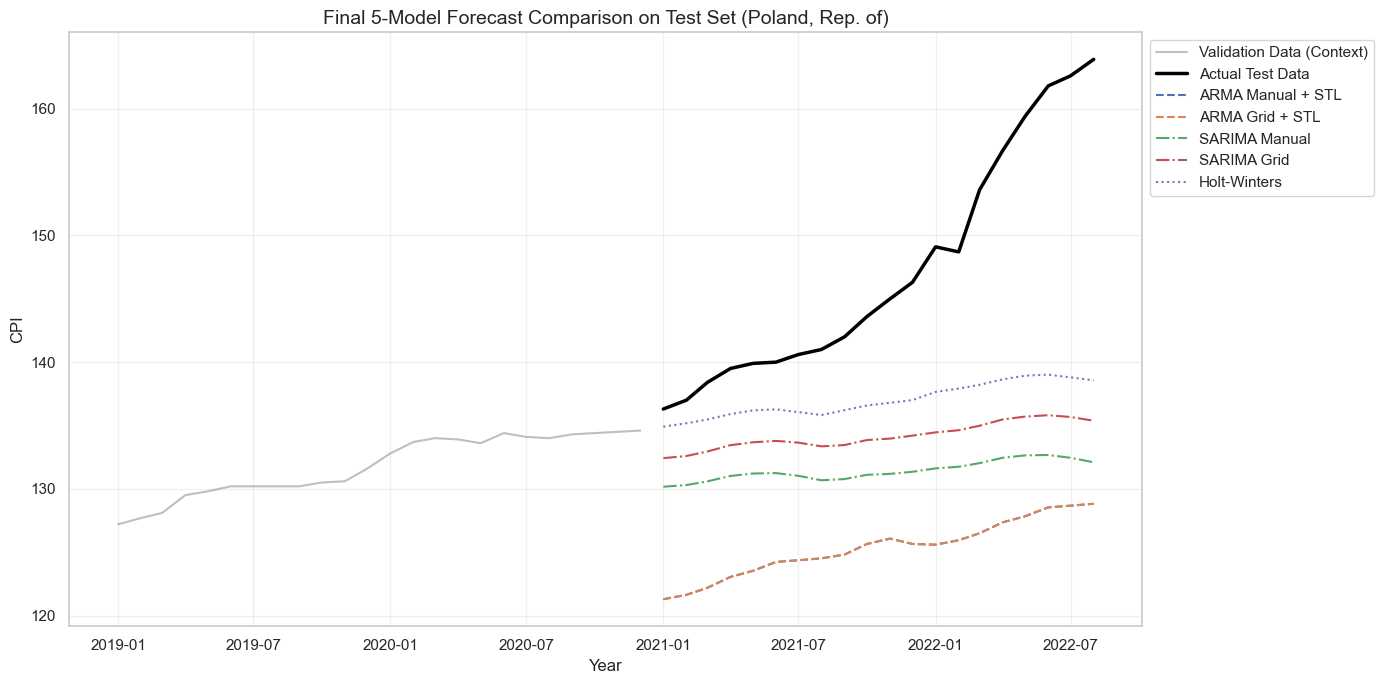

In [25]:
# =====================================================================
# 7. FINAL FORECAST PLOT
# =====================================================================
plt.figure(figsize=(14, 7))

# Plot historical context (last 2 years of validation to keep chart zoomed in)
plt.plot(val.iloc[-24:], label="Validation Data (Context)", color='gray', alpha=0.5)
plt.plot(test, label="Actual Test Data", color='black', linewidth=2.5)

# Plot Forecasts
plt.plot(pred_arma_man, label="ARMA Manual + STL", linestyle='--')
plt.plot(pred_arma_grid, label="ARMA Grid + STL", linestyle='--')
plt.plot(pred_sarima_man, label="SARIMA Manual", linestyle='-.')
plt.plot(pred_sarima_grid, label="SARIMA Grid", linestyle='-.')
plt.plot(pred_hw, label="Holt-Winters", linestyle=':')

plt.title(f"Final 5-Model Forecast Comparison on Test Set ({primary_country})", fontsize=14)
plt.xlabel("Year")
plt.ylabel("CPI")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Puts legend outside chart
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()